# Build your first model

Build a regression model, read its graph, and change a parameter to see which
quantities update. You need Liesel, pandas, and plotnine installed; graph plots also
need Graphviz. This notebook runs from top to bottom without external data.

## Generate data

We model $y_i \sim \mathcal{N}(\beta_0 + \beta_1 x_i, \sigma^2)$ with conditionally
independent observations. Here the second argument denotes variance; TFP's
`Normal` instead takes the standard deviation as `scale`.

In [1]:
import jax
import jax.numpy as jnp
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl

x_data = jnp.linspace(-1.0, 1.0, 80)
y_data = 1.0 + 2.0 * x_data + 0.7 * jax.random.normal(jax.random.key(42), (80,))

data = pd.DataFrame({"x": x_data, "y": y_data})

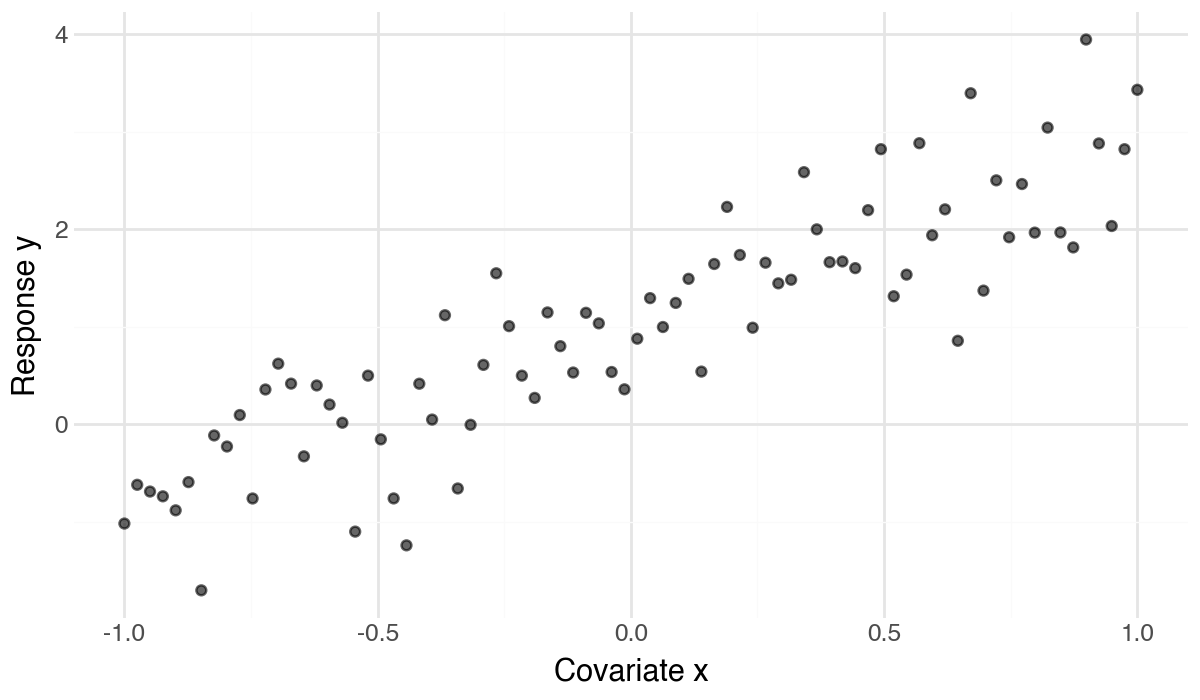

In [2]:
(
    p9.ggplot(data, p9.aes("x", "y"))
    + p9.geom_point(alpha=0.6, size=1.5)
    + p9.labs(x="Covariate x", y="Response y")
    + p9.theme_minimal()
    + p9.theme(figure_size=(6, 3.5))
).show()

The upward trend motivates a linear mean. The scatter around that trend is
response variation, which we model with an unknown positive variance.

## Define inputs

Give the two coefficients independent normal priors with standard deviation
2.5. Give variance a log-normal prior, which puts prior mass on positive values.
These are proper priors, which also let us simulate before fitting. Direct
assignments must still respect the positive constraint;
{doc}`../../model-transformations` shows how to use an unconstrained source.

In [3]:
prior_scale = lsl.Var.new_value(2.5, name="prior_scale")
beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=prior_scale),
    name="beta",
)

variance = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.LogNormal, loc=0.0, scale=0.5),
    name="variance",
)

x = lsl.Var.new_obs(x_data, name="x")

{meth}`new_param <liesel.model.Var.new_param>` marks quantities to estimate; the supplied values are starting
values. {meth}`new_obs <liesel.model.Var.new_obs>` marks observed data. The covariate `x` has no distribution
because we condition on it. {meth}`new_value <liesel.model.Var.new_value>` holds the fixed prior scale, which we
can still change interactively.

All four variables are **strong**: their values are supplied directly. This
describes where a value comes from, separately from its statistical role.

## Connect the response

In [4]:
mu = lsl.Var.new_calc(
    lambda x, b: b[0] + b[1] * x,
    x,
    beta,
    name="mu",
)

sigma = lsl.Var.new_calc(jnp.sqrt, variance, name="sigma")

y = lsl.Var.new_obs(
    y_data,
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)
model = lsl.Model(y)

{meth}`new_calc <liesel.model.Var.new_calc>` takes a function followed by its inputs. Its result is a **weak**
variable: `mu` and `sigma` are calculated rather than set directly. Passing
`beta`, not {attr}`beta.value <liesel.model.Var.value>`, keeps the dependency in the graph. {class}`Dist <liesel.model.Dist>` similarly
takes a distribution constructor and its inputs.

`Model(y)` discovers the response's inputs recursively. It evaluates the graph
at the current parameter values; it has not fitted the data.

## Read the model graph

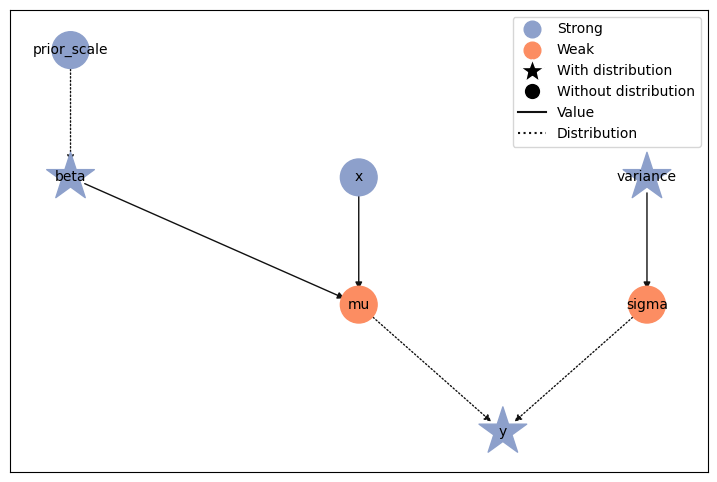

In [5]:
model.plot(width=9, height=6)

Arrows point from inputs to dependent variables. Solid edges supply values
to calculations; dotted edges supply distribution parameters. Blue variables
are strong and orange variables are weak. A star means a variable has a
distribution, so both the response and parameters with priors have stars.
It does not identify the observed role.

## Inspect the model

In [6]:
pd.DataFrame(
    [
        {
            "name": name,
            "strong": var.strong,
            "parameter": var.parameter,
            "observed": var.observed,
            "has_distribution": var.has_dist,
        }
        for name, var in model.vars.items()
    ]
).set_index("name")

,strong,parameter,observed,has_distribution
name,,,,
variance,True,True,False,True
x,True,False,True,False
prior_scale,True,False,False,False
sigma,False,False,False,False
beta,True,True,False,True
mu,False,False,False,False
y,True,False,True,True


{attr}`model.vars <liesel.model.Model.vars>` contains every variable. {attr}`model.parameters <liesel.model.Model.parameters>` selects `beta` and
`variance`, while {attr}`model.observed <liesel.model.Model.observed>` selects `x` and `y`. A calculated variable
can carry a density and a statistical role too; see
{doc}`../../model-distributions` for that less usual case.

In [7]:
y.log_prob.shape

(80,)

In [8]:
x.log_prob

0.0

In [9]:
pd.Series(
    {
        "log likelihood": float(model.log_lik),
        "log prior": float(model.log_prior),
        "log probability": float(model.log_prob),
    }
).round(3)

log likelihood    -173.167
log prior           -3.896
log probability   -177.063
dtype: float64

The response has 80 individual log densities. The model sums them for its
likelihood and adds the parameter prior contributions for its total. The
covariate has no distribution, so its contribution is zero. These density
values describe the current position; their magnitude alone does not measure
fit quality or convergence.

## Change a parameter

In [10]:
before = {
    "mean at first x": float(mu.value[0]),
    "log likelihood": float(model.log_lik),
    "variance log prior": float(variance.log_prob),
}
beta.value = jnp.array([1.0, 2.0])
after = {
    "mean at first x": float(mu.value[0]),
    "log likelihood": float(model.log_lik),
    "variance log prior": float(variance.log_prob),
}

In [11]:
pd.DataFrame({"before": before, "after": after}).round(3)

,before,after
mean at first x,0.000,-1.000
log likelihood,-173.167,-87.078
variance log prior,-0.226,-0.226


The mean and likelihood change automatically. The variance prior is unchanged
because it does not depend on `beta`. The coefficient prior also changes, but
is omitted from this small table. Calculated values are cached and only
recomputed when their inputs change.

We supplied the data-generating coefficients ourselves for this demonstration;
the update is not an inference result.

## Check starting values

In [12]:
model.diagnose()[
    ["name", "value_n_nan", "value_n_inf", "log_prob_n_nan", "log_prob_n_inf"]
]

,name,value_n_nan,value_n_inf,log_prob_n_nan,log_prob_n_inf
0,variance,0,0,0,0
1,x,0,0,NaN,NaN
2,prior_scale,0,0,NaN,NaN
3,sigma,0,0,NaN,NaN
4,beta,0,0,0,0
5,mu,0,0,NaN,NaN
6,y,0,0,0,0


The counts should be zero where a quantity exists. Missing entries (`NaN`) for log
probabilities mean the variable has no distribution; they are not failed density
evaluations. Finite starting values
are useful, but do not establish a good model or a converged fit.

Continue with {doc}`../../optimization` for point estimates or
{doc}`../md/01c-transform` for posterior sampling with a transformed variance.
{doc}`../../model-modification` shows how to change priors and dependencies.
For a complete fit followed by predictions, use
{doc}`12-model-predictions`.